In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import sys
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.transforms import Normalize
from torchvision.transforms import ToTensor
import os

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.3
pandas 3.0.1
sklearn 1.8.0
torch 2.10.0+cu128
cuda:0


# 加载数据

In [15]:
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

#计算均值和方差
def cal_mean_std(ds):
    mean = 0.
    std = 0.
    for image_input, _ in ds:
        # 遍历每张图片, image.shape=[1,28,28]
        mean += image_input.mean(dim=(1, 2))
        # 计算每张图片的均值, dim=(1, 2)表示每张图片的宽高共同求均值
        std += image_input.std(dim=(1, 2))
    mean /= len(ds)
    std /= len(ds)
    return mean, std
    # 单通道的图, mean结果是0维张量 
    # 如果是多通道的图, mean是1维张量, 传入Normalize时最好使用tolist


mean_train, std_train = cal_mean_std(train_ds)
transforms=nn.Sequential(Normalize(mean_train, std_train))

In [16]:
import random


def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

In [17]:
# 数据加载器, 将其进行分批和其他处理
train_ld = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)  
#batch_size批大小, shuffle洗牌, 这是为了避免局部最优解
val_ld = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)
# 验证集不需要打乱

## 定义模型

这里没有用`nn.Linear`的默认初始化，而是采用了xavier均匀分布去初始化全连接层的权重

xavier初始化出自论文 《Understanding the difficulty of training deep feedforward neural networks》，适用于使用`tanh`和`sigmoid`激活函数的方法。这里模型采用的是`relu`激活函数，采用He初始化（何凯明初始化）会更加合适。

He初始化出自论文 《Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification》

In [18]:
class NeuralNetwork(nn.Module):
    def __init__(self, layers_num=2):
        super().__init__()
        self.transforms = transforms 
        # 预处理层，标准化
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 100),
            nn.ReLU(),
        )
        # 添加第一层
        for i in range(1, layers_num):
            self.linear_relu_stack.add_module(f"Linear_{i}", nn.Linear(100, 100))
            self.linear_relu_stack.add_module(f"ReLu_{i}", nn.ReLU())
            # 加上layer_num个全连接层和激活函数
        self.linear_relu_stack.add_module("Output Layer", nn.Linear(100, 10))
        # 添加输出层
        
        self.init_weights()
        # 初始化权重
        
    def init_weights(self):
        # 使用 xavier 均匀分布来初始化全连接层的权重
        for m in self.modules():
            # print(m)
            # print('-'*50)
            if isinstance(m, nn.Linear):
                # isinstance, 判断m是否为nn.Linear
                nn.init.xavier_uniform_(m.weight) 
                # xavier 均匀分布初始化权重, 公式是 6/fan_in + fan_out
                nn.init.zeros_(m.bias) 
                # 全零初始化偏置项
    def forward(self, x):
        x = self.transforms(x) 
        # 标准化
        # x.shape [batch size, 1, 28, 28]
        x = self.flatten(x)  
        # flattened x.shape [batch size, 28 * 28]
        logits = self.linear_relu_stack(x)
        # logits.shape [batch size, 10]
        return logits
total=0
# 设置层数为20层, 计算总参数量
for idx, (key, value) in enumerate(NeuralNetwork(20).named_parameters()):
    # named_parameters()返回一个迭代器, 里面的每一项是(参数名, 参数)
    # enumerate()同时得到索引和元素
    total+=np.prod(value.shape)
    # value是一个tensor, prod将ndarray里的每个元素相乘(product)
    # 累加起来得到总参数量
total 

np.int64(271410)

In [19]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience 
        # 多少个step没有提升min_delta就停止训练
        self.min_delta = min_delta 
        # 最小的提升幅度
        self.best_metric = -1
        self.counter = 0 
        # 计数器, 记录多少个step没有提升
        
    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            # 将当前算子作为最佳算子
            self.counter = 0
        else: 
            self.counter += 1
            # 假如这一步没有更优, 则计数器加一
            
    @property 
    # property装饰器指将方法变成属性
    def early_stop(self):
        return self.counter >= self.patience

In [20]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_epoch=1, save_step=500, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch. 
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir # 保存路径
        self.save_step = save_step # 保存步数
        self.save_best_only = save_best_only # 是否只保存最好的模型
        self.best_metrics = -1 # 最好的指标, 指标不可能为负数, 所以初始化为-1
        self.save_epoch = save_epoch
        # mkdir
        if not os.path.exists(self.save_dir): 
            # 如果不存在保存路径, 则创建
            os.mkdir(self.save_dir)
        
    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0: 
            # 每隔save_step步保存一次
            return
        
        if self.save_best_only:
            assert metric is not None,'metric is not None' 
            # 必须传入metric
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best_dnn.ckpt")) 
                # os.path.join表示路径拼接, 相当于save_dir+"best.ckpt"
                # 保存最好的模型, 覆盖之前的模型
                # 不保存step, 只保存state_dict, 即模型参数, 不保存优化器参数
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt")) 
            # 保存每个step的模型, 不覆盖之前的模型
            # 保存step, 保存state_dict, 即模型参数, 不保存优化器参数

In [21]:
network = NeuralNetwork(10)
network.to(device)
# 1. 定义损失函数
loss_fct = nn.CrossEntropyLoss()
# 输出时将logits经过softmax, 和转换为one-hot编码的标签值计算交叉熵损失
# 得到的是标量(0维张量)

# 2. 定义优化器 采用SGD(随机梯度下降, stochastic gradient descent)
opt = torch.optim.SGD(network.parameters(), lr=0.001, momentum=0.9)
# lr学习率, momentum动量

In [22]:
for name, param in network.named_parameters(): 
    # 打印模型参数
    print(name)
    print(param.shape)

linear_relu_stack.0.weight
torch.Size([100, 784])
linear_relu_stack.0.bias
torch.Size([100])
linear_relu_stack.Linear_1.weight
torch.Size([100, 100])
linear_relu_stack.Linear_1.bias
torch.Size([100])
linear_relu_stack.Linear_2.weight
torch.Size([100, 100])
linear_relu_stack.Linear_2.bias
torch.Size([100])
linear_relu_stack.Linear_3.weight
torch.Size([100, 100])
linear_relu_stack.Linear_3.bias
torch.Size([100])
linear_relu_stack.Linear_4.weight
torch.Size([100, 100])
linear_relu_stack.Linear_4.bias
torch.Size([100])
linear_relu_stack.Linear_5.weight
torch.Size([100, 100])
linear_relu_stack.Linear_5.bias
torch.Size([100])
linear_relu_stack.Linear_6.weight
torch.Size([100, 100])
linear_relu_stack.Linear_6.bias
torch.Size([100])
linear_relu_stack.Linear_7.weight
torch.Size([100, 100])
linear_relu_stack.Linear_7.bias
torch.Size([100])
linear_relu_stack.Linear_8.weight
torch.Size([100, 100])
linear_relu_stack.Linear_8.bias
torch.Size([100])
linear_relu_stack.Linear_9.weight
torch.Size([100, 

In [23]:
from sklearn.metrics import accuracy_score


# 3.编写评估函数
@torch.no_grad()
# 装饰器, 禁止反向传播, 节省内存
def evaluating(model, dataloader, loss_function):
    loss_list = []
    # 记录损失
    pred_list = []
    # 记录预测
    label_list = []
    # 记录标签
    for data, label in dataloader:
        # 一共10000/32=312个batch
        data = data.to(device)
        # 把tensor放入GPU
        label = label.to(device)
        # 转到GPU
        logits = model(data)
        # 前向计算
        loss = loss_function(logits, label)
        # 使用loss_function计算本batch的损失, 得到的实际上是一个张量
        loss_list.append(loss.item())
        # 记录损失, item把tensor转换为数值, 注意item只能处理0维张量  

        pred = logits.argmax(axis=-1)
        # 验证集预测, argmax返回最大值索引数组
        # logits是一个(32, 10)数组, 求出的pred是一个(32, )数组,
        # 即每个样本使用十个标签概率的最大值的索引作为预测值
        pred_list.extend(pred.cpu().numpy().tolist())
        # numpy()将PyTorch张量转换为NumPy数组。只有当张量在CPU上时, 这个转换才是合法的
        label_list.extend(label.cpu().numpy().tolist())

    acc = accuracy_score(label_list, pred_list)
    # 计算准确率
    return np.mean(loss_list), acc

In [24]:
save_ckpt_callback = SaveCheckpointsCallback("checkpoints", save_best_only=True)
early_stop_callback = EarlyStopCallback(patience=5)

In [25]:
# 4.训练

def training(model, train_loader, val_loader, epoch, loss_function,
             optimizer,
             tensorboard=None,
             save_ckpt=None,
             early_stop=None,
             eval_step=500):
    """
    训练函数
    :param model: 模型
    :param train_loader: 训练数据集
    :param val_loader: 验证数据集
    :param epoch: 训练轮数
    :param loss_function: 损失函数
    :param optimizer: 优化器
    :param tensorboard: 可视化回调函数
    :param save_ckpt: 保存回调函数
    :param early_stop: 早停回调函数
    :param eval_step: 每训练多少batch对验证集进行评估
    :return: dict
    """
    record_dict = {
        "train": [],
        "val": []
    }
    # 存储训练集和测试集的损失和准确率
    global_step = 0
    # 记录总步数, 在进度条中使用
    model.train()
    # 进入训练模式
    # 对于一些特定层很重要：
    # Dropout → 在训练阶段才会随机丢弃神经元
    # BatchNorm → 使用 batch 的均值和方差
    with (tqdm(total=epoch * len(train_loader)) as pbar): 
        # with是上下文管理器, 保证进度条结束后自动关闭
        # 进度条一共 len(train_loader)*epoch 步
        for epoch_id in range(epoch): 
            # 训练epoch次
            for data, label in train_loader: 
                # 每次迭代得到一个batch
                # 执行次数是60000/32=1875
                data = data.to(device) 
                # datas尺寸是[batch_size,1,28,28], 转到GPU
                label = label.to(device) 
                # labels尺寸是[batch_size], 转到GPU
                optimizer.zero_grad()
                # 梯度清空, PyTorch会累加梯度, 要避免上一batch的梯度影响后面
                logits = model(data)
                # 正向计算, 得到未经过softmax的输出
                loss = loss_function(logits, label)
                # 计算损失
                loss.backward()
                # 梯度回传, loss.backward()会计算梯度, loss对模型参数(权重和偏置)求导
                optimizer.step()
                # 调整优化器, 改变学习率(如果使用了学习率调度器), 更新模型参数和一些其他值
                # 梯度计算并存储在模型参数的 .grad 属性中
                # 优化器使用这些存储的梯度来更新模型参数

                pred = logits.argmax(axis=-1) 
                # 对训练集预测
                acc = accuracy_score(label.cpu().numpy(), pred.cpu().numpy()) 
                # 每个batch计算准确率
                loss = loss.cpu().item()
                # loss这一0维张量转换为数值
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                }) 
                # 记录训练集信息, 每一步的损失, 准确率, 步数
                
                if global_step % eval_step == 0:
                    model.eval() 
                    # 进入评估模式
                    # Dropout 停用
                    # BatchNorm 使用训练时统计值
                    val_loss, val_acc = evaluating(model, val_loader, 
                                                   loss_function)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train() 
                    # 进入训练模式
                    
                    # 1. 使用tensorboard可视化
                    if tensorboard is not None:
                        tensorboard(
                            global_step, 
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"], # 取出当前学习率
                            )
                    
                    # 2. 保存模型权重save model checkpoint
                    if save_ckpt is not None:
                        save_ckpt(global_step, model.state_dict(), metric=val_acc) 
                        # 保存最好的模型, 覆盖之前的模型
                        # 保存step, 保存state_dict,通过metric判断是否保存最好的模型

                    # 3. 早停Early Stop
                    if early_stop is not None:
                        early_stop(val_acc) 
                        # 验证集准确率不再提升, 则停止训练
                        if early_stop.early_stop:
                            # 注意之前有property装饰器, 将方法作为属性计算
                            # 属性的值就是方法的返回值
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                global_step += 1 
                # 全局步数加1
                pbar.update(1) 
                # 更新进度条
                pbar.set_postfix({"epoch": epoch_id}) 
                # 设置进度条显示信息
        
    return record_dict

In [26]:
record=training(network, train_ld, val_ld, epoch=100, loss_function=loss_fct, optimizer=opt, tensorboard=None, save_ckpt=save_ckpt_callback, early_stop=early_stop_callback, eval_step=1000)

  0%|          | 0/187500 [00:00<?, ?it/s]

Early stop at epoch 5 / global_step 11000


In [27]:
print(pd.DataFrame(record["train"]).set_index("step")[-50:])

           loss      acc
step                    
10951  0.351056  0.84375
10952  0.151301  0.96875
10953  0.310685  0.84375
10954  0.289523  0.90625
10955  0.422645  0.84375
10956  0.411994  0.93750
10957  0.324045  0.90625
10958  0.122781  0.93750
10959  0.137363  0.96875
10960  0.252782  0.87500
10961  0.337784  0.87500
10962  0.137906  0.93750
10963  0.109770  0.96875
10964  0.200445  0.93750
10965  0.274601  0.93750
10966  0.212482  0.93750
10967  0.279516  0.93750
10968  0.433503  0.84375
10969  0.436942  0.84375
10970  0.293699  0.90625
10971  0.239683  0.87500
10972  0.418480  0.87500
10973  0.116060  0.96875
10974  0.338053  0.87500
10975  0.329096  0.84375
10976  0.253654  0.93750
10977  0.198089  0.96875
10978  0.282776  0.84375
10979  0.303725  0.84375
10980  0.283635  0.81250
10981  0.213755  0.87500
10982  0.471609  0.84375
10983  0.361409  0.87500
10984  0.317568  0.78125
10985  0.221401  0.93750
10986  0.069213  1.00000
10987  0.272066  0.90625
10988  0.338166  0.87500


Index(['loss', 'acc'], dtype='str')
step
0        0.03125
500      0.90625
1000     0.81250
1500     0.87500
2000     0.90625
2500     0.90625
3000     0.90625
3500     0.87500
4000     0.81250
4500     0.84375
5000     0.96875
5500     0.87500
6000     0.87500
6500     0.84375
7000     0.90625
7500     0.87500
8000     0.93750
8500     0.93750
9000     0.96875
9500     0.81250
10000    0.93750
10500    0.93750
11000    0.96875
Name: acc, dtype: float64
step
0        0.155867
1000     0.835017
2000     0.856667
3000     0.869783
4000     0.868467
5000     0.878383
6000     0.886533
7000     0.890333
8000     0.894233
9000     0.883467
10000    0.894817
11000    0.895550
Name: acc, dtype: float64


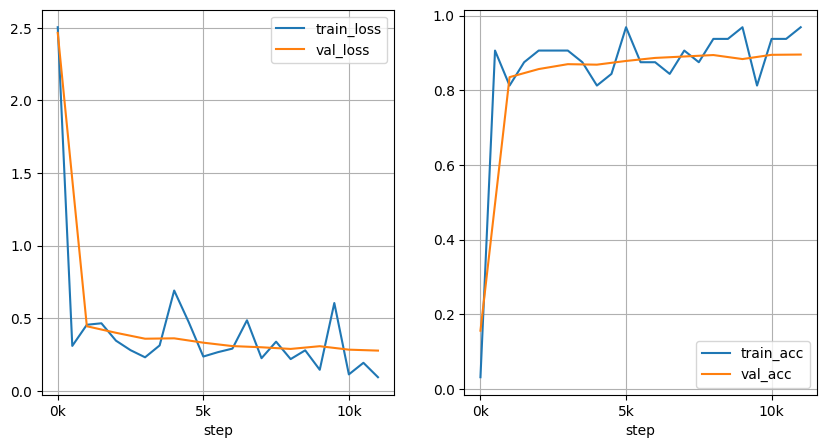

In [28]:
def plot_learning_curves(record_dict, sample_step=500):
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # set_index将行索引设置成step, 每隔sample_step取一次
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    last_step = train_df.index[-1]
    # 最后一步的步数
    print(train_df.columns)
    print(train_df['acc'])
    print(val_df['acc'])
    
    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for index, item in enumerate(train_df.columns):
        # enumerate同时得到索引和值
        # index = 0, 1, item = 'loss', 'acc'
        # print(train_df[item].values)
        axs[index].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[index].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[index].grid()
        axs[index].legend()
        axs[index].set_xticks(range(0, train_df.index[-1], 5000)) 
        axs[index].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, last_step, 5000)))
        axs[index].set_xlabel("step")
    
    plt.show()

plot_learning_curves(record)